In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo
import cartopy.crs as ccrs
import gsw

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


from utils import *
from utils_ice_th import *

In [2]:
dssnow = xr.open_dataset('data/data_snow/snow_west.nc')
lat_cond = (dssnow['latitude'] >= 84.5) & (dssnow['latitude'] <= 85.5)
long_cond = (dssnow['longitude'] >= -0.5) & (dssnow['longitude'] <= 0.5)
dssnow_sliced = dssnow.where(lat_cond & long_cond, drop=True)
dssnow_avg = dssnow_sliced.mean(dim = ['x', 'y'])
dssnow_avg_even_days = dssnow_avg.resample(valid_time='12H').interpolate('linear')

y_snow = dssnow_avg_even_days['sitd'].values

/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


In [3]:
dsice1 = xr.open_dataset('data/data_stream-oper_stepType-accum.nc').load()
dsice2 = xr.open_dataset('data/data_stream-oper_stepType-instant.nc').load()
dsice = xr.merge([dsice1, dsice2])

dssnow = xr.open_dataset('data/ed4ae72f22183d05c26154325e5eafa4.nc').load()

dsice

<xarray.Dataset> Size: 11MB
Dimensions:     (valid_time: 15340, latitude: 5, longitude: 5)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 123kB 2003-01-01 ... 2023-12-31T1...
  * latitude    (latitude) float64 40B 85.5 85.25 85.0 84.75 84.5
  * longitude   (longitude) float64 40B -0.5 -0.25 0.0 0.25 0.5
    expver      (valid_time) <U4 245kB '0001' '0001' '0001' ... '0001' '0001'
Data variables:
    slhf        (valid_time, latitude, longitude) float32 2MB -8.493e+04 ... ...
    ssr         (valid_time, latitude, longitude) float32 2MB 3.6e-12 ... 3.6...
    str         (valid_time, latitude, longitude) float32 2MB -6.282e+04 ... ...
    sshf        (valid_time, latitude, longitude) float32 2MB 5.174e+04 ... -...
    t2m         (valid_time, latitude, longitude) float32 2MB 267.9 ... 258.1
    u10         (valid_time, latitude, longitude) float32 2MB 3.488 ... 2.621
    v10         (valid_time, latitude, longitude) float32 2MB 17.29 ... -5.7
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-02-28T13:16 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
t2m, u10, v10, slhf, ssr, str, sshf = mise_en_forme_daily(dsice)
snow_depth = mise_en_forme_snow(dssnow)

t2m = t2m - 273.15

In [5]:
fs = surface_flux_downwards(ssr, str, slhf, sshf)

time_mod, y_mod = ice_thickness_th(2.1, t2m, fs, snow_depth, duree = 15*365)

Text(0.5, 0, 'Time (days)')

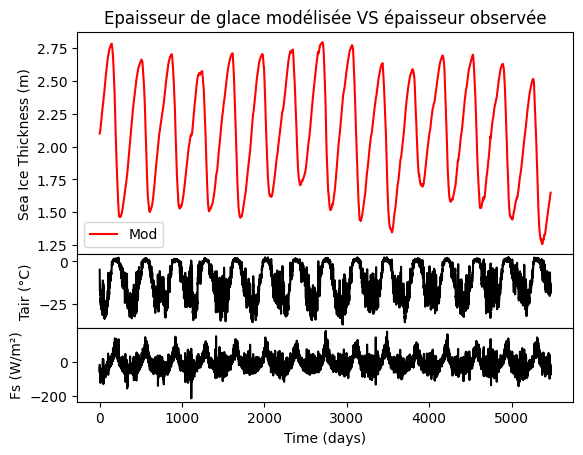

In [6]:
#Affichage des courbes
grid = plt.GridSpec(5, 1, hspace=0, wspace=0)
plt.style.use('default')
#plt.xkcd()
#plt.rcdefaults()
main = plt.subplot(grid[0:3], xticklabels=[])
main.plot(time_mod, y_mod, c = 'r', label = 'Mod')#, linestyle = ',')
main.set_title('Epaisseur de glace modélisée VS épaisseur observée')
main.set_ylabel('Sea Ice Thickness (m)')
main.legend()

dev = plt.subplot(grid[3], xticklabels=[])
plt.plot(time_mod, t2m[:len(time_mod)], c = 'black', label = 'Obs')#, linestyle = ',')
dev.set_ylabel('Tair (°C)')
dev.set_xlabel('Time (days)')

dev2 = plt.subplot(grid[4])
plt.plot(time_mod, fs[:len(time_mod)], c = 'black', label = 'Obs')#, linestyle = ',')
dev2.set_ylabel('Fs (W/m²)')
dev2.set_xlabel('Time (days)')

In [7]:
#ds = xr.open_dataset('data/surface_SIT.nc').load()

# Select the region of interest
#ds = ds.sel(latitude=slice(84.5, 85.5))
#ds = ds.sel(longitude=slice(-0.5, 0.5))

# Average over latitude and longitude
#ds = ds.mean(dim=['latitude', 'longitude'])

# Extract the SIT values
#sitobs = ds['SIT'].values

# Convert the time coordinates to days
#time = ds['time'].to_index()

#time_days = pd.date_range(start=time[0], end=time[-1], freq='D')
#sitobs_daily = np.repeat(sitobs, 2*time.days_in_month)

# Plot SIT observations along the time axis
#plt.figure(figsize=(10, 5))
#plt.plot(time_days, sitobs_daily[:len(time_days)])  # Ensure the lengths match
#plt.xlabel('Time (days)')
#plt.ylabel('Sea Ice Thickness (SIT)')
#plt.title('Sea Ice Thickness over Time')
#plt.grid(True)
#plt.show()

/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


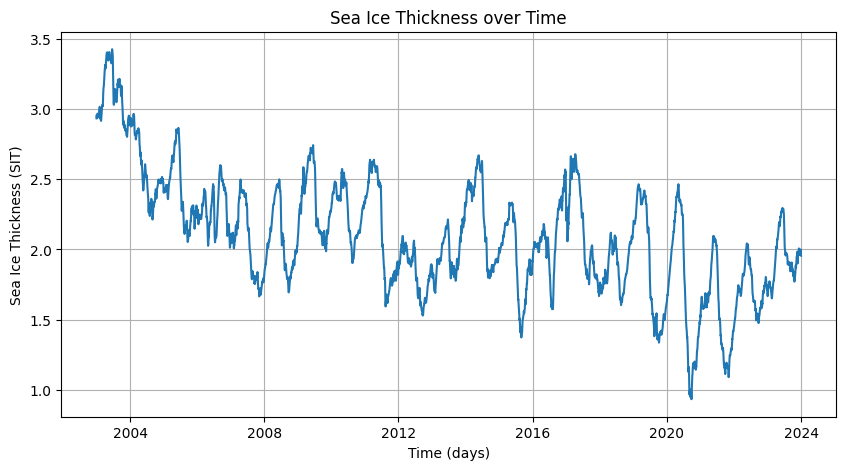

In [8]:
dsobs = xr.open_dataset('data/surface_SIT.nc').load()
dsobs = dsobs.mean(dim=['latitude', 'longitude'])

#timeobs = dsobs['time']
#sitobs = dsobs['SIT'].values

dsobs_resampled = dsobs.resample(time='12H').interpolate('linear')
timeobs = dsobs_resampled['time']
sitobs = dsobs_resampled['SIT'].values

plt.figure(figsize=(10, 5))
plt.plot(timeobs, sitobs)  # Ensure the lengths match
plt.xlabel('Time (days)')
plt.ylabel('Sea Ice Thickness (SIT)')
plt.title('Sea Ice Thickness over Time')
plt.grid(True)
plt.show()

In [9]:
dsobs_resampled

<xarray.Dataset> Size: 245kB
Dimensions:  (time: 15339)
Coordinates:
  * time     (time) datetime64[ns] 123kB 2003-01-01 ... 2023-12-31
Data variables:
    SIT      (time) float64 123kB 2.934 2.943 2.952 2.955 ... 1.955 1.955 1.955

In [10]:
dsice

<xarray.Dataset> Size: 11MB
Dimensions:     (valid_time: 15340, latitude: 5, longitude: 5)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 123kB 2003-01-01 ... 2023-12-31T1...
  * latitude    (latitude) float64 40B 85.5 85.25 85.0 84.75 84.5
  * longitude   (longitude) float64 40B -0.5 -0.25 0.0 0.25 0.5
    expver      (valid_time) <U4 245kB '0001' '0001' '0001' ... '0001' '0001'
Data variables:
    slhf        (valid_time, latitude, longitude) float32 2MB -8.493e+04 ... ...
    ssr         (valid_time, latitude, longitude) float32 2MB 3.6e-12 ... 3.6...
    str         (valid_time, latitude, longitude) float32 2MB -6.282e+04 ... ...
    sshf        (valid_time, latitude, longitude) float32 2MB 5.174e+04 ... -...
    t2m         (valid_time, latitude, longitude) float32 2MB 267.9 ... 258.1
    u10         (valid_time, latitude, longitude) float32 2MB 3.488 ... 2.621
    v10         (valid_time, latitude, longitude) float32 2MB 17.29 ... -5.7
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-02-28T13:16 GRIB to CDM+CF via cfgrib-0.9.1...

Text(0.5, 0, 'Time (days)')

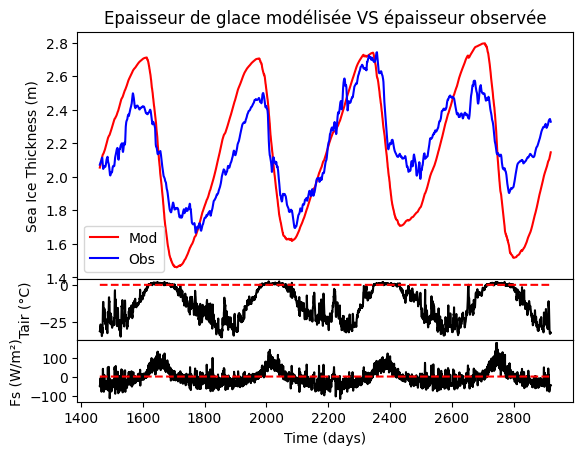

In [11]:
start = 2*(4*365 + 1)
end = 2*(8*365 + 1)


#Affichage des courbes
grid = plt.GridSpec(6, 1, hspace=0, wspace=0)
plt.style.use('default')
#plt.xkcd()
#plt.rcdefaults()
main = plt.subplot(grid[0:4], xticklabels=[])
main.plot(time_mod[start:end], y_mod[start:end], c = 'r', label = 'Mod')#, linestyle = ',')
main.plot(time_mod[start:end], sitobs[start:end], c = 'b', label = 'Obs')#, linestyle = ',')
main.set_title('Epaisseur de glace modélisée VS épaisseur observée')
main.set_ylabel('Sea Ice Thickness (m)')
main.legend()

dev = plt.subplot(grid[4], xticklabels=[])
plt.plot(time_mod[start:end], t2m[start:end], c = 'black', label = 'Obs')#, linestyle = ',')
plt.plot(time_mod[start:end], 0*fs[start:end], c = 'red', linestyle = '--' , label = 'Obs')#, linestyle = ',')
dev.set_ylabel('Tair (°C)')
dev.set_xlabel('Time (days)')

dev2 = plt.subplot(grid[5:6])
plt.plot(time_mod[start:end], fs[start:end], c = 'black', label = 'Obs')#, linestyle = ',')
plt.plot(time_mod[start:end], 0*fs[start:end], c = 'red', linestyle = '--' , label = 'Obs')#, linestyle = ',')
dev2.set_ylabel('Fs (W/m²)')
dev2.set_xlabel('Time (days)')

(3.0, -0.5)

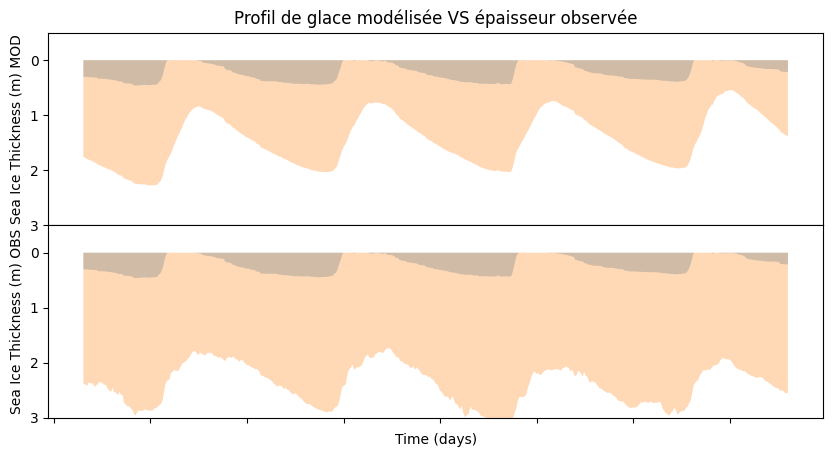

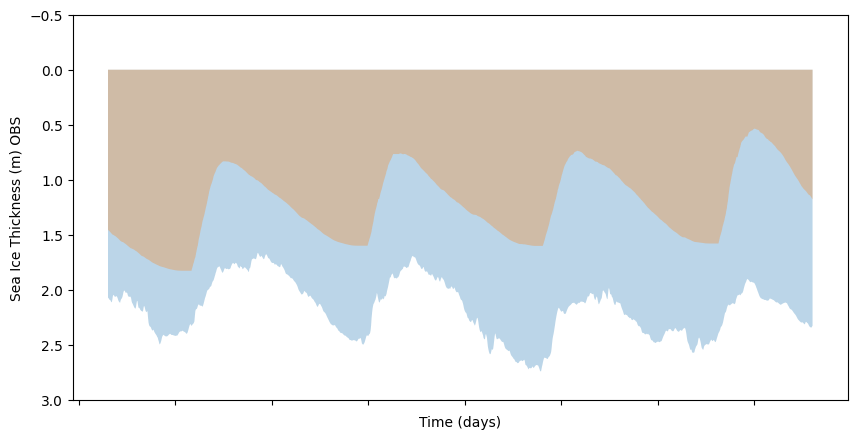

In [18]:
#Représentation full

plt.figure(figsize=(10, 5))

grid = plt.GridSpec(6, 1, hspace=0, wspace=0)
plt.style.use('default')
#plt.xkcd()
#plt.rcdefaults()
main = plt.subplot(grid[0:3], xticklabels=[])
main.fill_between(time_mod[start:end], y_snow[start:end], 0, alpha=0.3)  # Fill the area between the curve and x = 0
main.fill_between(time_mod[start:end], y_snow[start:end] + y_mod[start:end], 0, alpha=0.3)  # Fill the area between the curve and x = 0
main.set_title('Profil de glace modélisée VS épaisseur observée')
main.set_ylabel('Sea Ice Thickness (m) MOD')
main.set_ylim(3,-0.5)

dev = plt.subplot(grid[3:6], xticklabels=[])
dev.fill_between(time_mod[start:end], y_snow[start:end], 0, alpha=0.3)  # Fill the area between the curve and x = 0
dev.fill_between(time_mod[start:end], y_snow[start:end] + sitobs[start:end], 0, alpha=0.3)  # Fill the area between the curve and x = 0
dev.set_ylabel('Sea Ice Thickness (m) OBS')
dev.set_xlabel('Time (days)')
dev.set_ylim(3,-0.5)

plt.figure(figsize=(10, 5))

grid = plt.GridSpec(3, 1, hspace=0, wspace=0)
dev2 = plt.subplot(grid[0:3], xticklabels=[])
#dev2.plot(time_mod[start:end], sitobs[start:end])#, linestyle = ',')
dev2.fill_between(time_mod[start:end], sitobs[start:end], 0, alpha=0.3)  # Fill the area between the curve and x = 0
dev2.fill_between(time_mod[start:end], y_mod[start:end], 0, alpha=0.3)  # Fill the area between the curve and x = 0
dev2.set_ylabel('Sea Ice Thickness (m) OBS')
dev2.set_xlabel('Time (days)')
dev2.set_ylim(3,-0.5)


In [13]:
snow_depth = y_snow

time_mod, y_mod = ice_thickness_th(2.1, t2m, fs, snow_depth, duree = 15*365)

(3.0, -0.5)

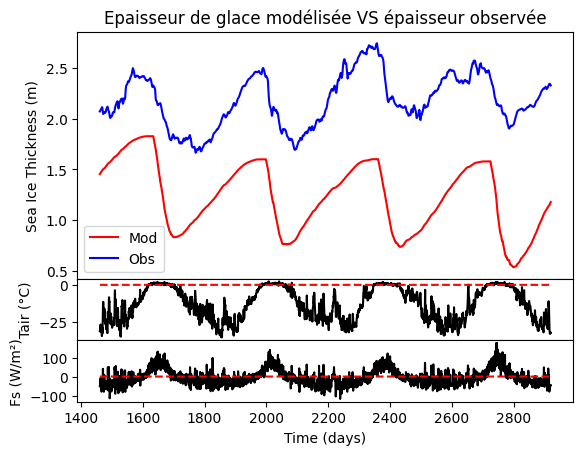

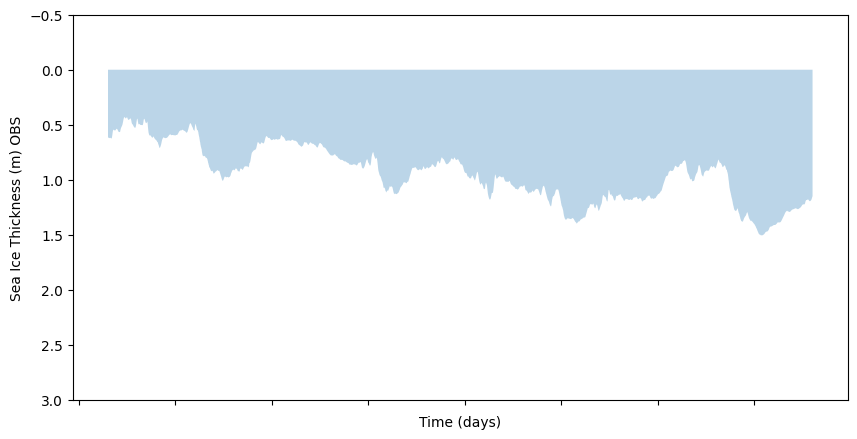

In [14]:
start = 2*(4*365 + 1)
end = 2*(8*365 + 1)


#Affichage des courbes
grid = plt.GridSpec(6, 1, hspace=0, wspace=0)
plt.style.use('default')
#plt.xkcd()
#plt.rcdefaults()
main = plt.subplot(grid[0:4], xticklabels=[])
main.plot(time_mod[start:end], y_mod[start:end], c = 'r', label = 'Mod')#, linestyle = ',')
main.plot(time_mod[start:end], sitobs[start:end], c = 'b', label = 'Obs')#, linestyle = ',')
main.set_title('Epaisseur de glace modélisée VS épaisseur observée')
main.set_ylabel('Sea Ice Thickness (m)')
main.legend()

dev = plt.subplot(grid[4], xticklabels=[])
plt.plot(time_mod[start:end], t2m[start:end], c = 'black', label = 'Obs')#, linestyle = ',')
plt.plot(time_mod[start:end], 0*fs[start:end], c = 'red', linestyle = '--' , label = 'Obs')#, linestyle = ',')
dev.set_ylabel('Tair (°C)')
dev.set_xlabel('Time (days)')

dev2 = plt.subplot(grid[5:6])
plt.plot(time_mod[start:end], fs[start:end], c = 'black', label = 'Obs')#, linestyle = ',')
plt.plot(time_mod[start:end], 0*fs[start:end], c = 'red', linestyle = '--' , label = 'Obs')#, linestyle = ',')
dev2.set_ylabel('Fs (W/m²)')
dev2.set_xlabel('Time (days)')

plt.figure(figsize=(10, 5))

grid = plt.GridSpec(3, 1, hspace=0, wspace=0)
dev3 = plt.subplot(grid[0:3], xticklabels=[])
#dev2.plot(time_mod[start:end], sitobs[start:end])#, linestyle = ',')
dev3.fill_between(time_mod[start:end], sitobs[start:end] - y_mod[start:end], 0, alpha=0.3)  # Fill the area between the curve and x = 0
dev3.set_ylabel('Sea Ice Thickness (m) OBS')
dev3.set_xlabel('Time (days)')
dev3.set_ylim(3,-0.5)

